In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# ─────────────────────────────
# Load data
# ─────────────────────────────
chess = pd.read_csv("../data/raw/chess_games.csv")
registry = pd.read_csv("../data/raw/player_registry.csv")


In [3]:
# ─────────────────────────────
# Merge datasets
# ─────────────────────────────
merged = pd.merge(
    chess[['game_id', 'white_id', 'white_rating', 'winner', 'rated', 'turns']],
    registry.rename(columns={'username': 'white_id'}),
    on='white_id',
    how='left'
)

In [7]:
# ─────────────────────────────
# Q16 — Missing registry entries
# ─────────────────────────────
q16 = merged['country'].isnull().sum()
print("Q16 - Missing registry entries:", q16, "\n")
# Q16 - Missing registry entries: 15899 

Q16 - Missing registry entries: 15899 



In [9]:
# ─────────────────────────────
# Q17 — Country inconsistencies (before cleaning)
# ─────────────────────────────
q17 = merged['country'].nunique()
print("Q17 - Country inconsistencies (before cleaning):", q17, "\n")
# Q17 - Country inconsistencies (before cleaning): 29 


Q17 - Country inconsistencies (before cleaning): 29 



In [10]:
# ─────────────────────────────
# Standardize countries
# ─────────────────────────────
country_map = {
    'RUS': 'Russia',
    'US': 'United States',
    'USA': 'United States',
    'united states': 'United States',
    'UA': 'Ukraine',
    'GB': 'United Kingdom'
}
merged['country'] = merged['country'].map(country_map).fillna(merged['country'])


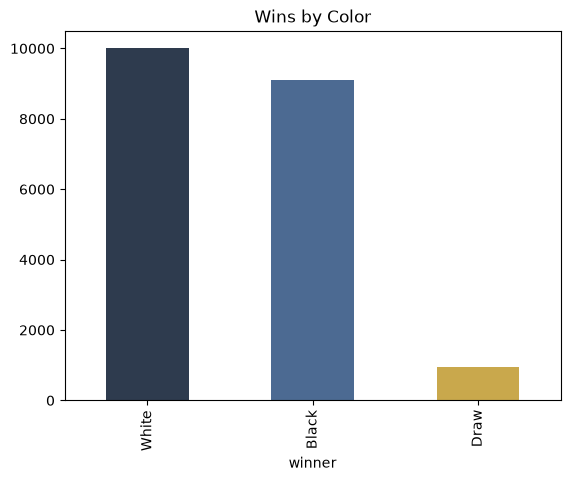

In [18]:
# ─────────────────────────────
# Q18 — Wins by color (bar chart)
# ─────────────────────────────
os.makedirs("../output", exist_ok=True)

win_counts = chess['winner'].value_counts()

plt.figure()

win_counts.plot(
    kind='bar',
    color=['#2E3B4E', '#4C6A92', '#C9A84C'],
    title="Wins by Color"
)

plt.savefig("../output/plots/wins_by_color.png")
plt.show()


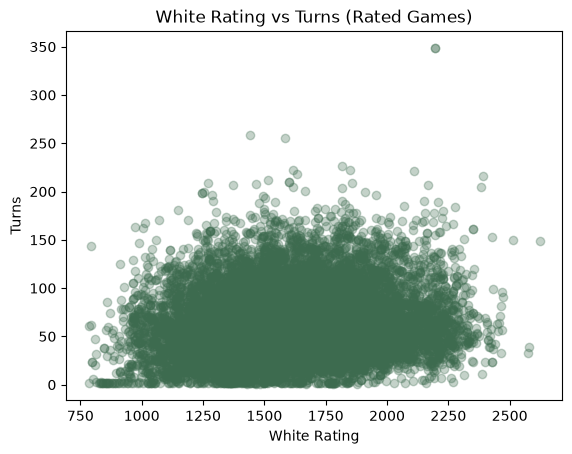

In [26]:
# ─────────────────────────────
# Q19 — Scatter: rating vs turns (rated games only)
# ─────────────────────────────
rated = merged[merged['rated'] == True]

plt.figure()

plt.scatter(
    rated['white_rating'],
    rated['turns'],
    alpha=0.3,
    color='#3D6B4F'
)

plt.title("White Rating vs Turns (Rated Games)")
plt.xlabel("White Rating")
plt.ylabel("Turns")

plt.savefig("../output/plots/rating_vs_turns.png")
plt.show()

<Figure size 800x500 with 0 Axes>

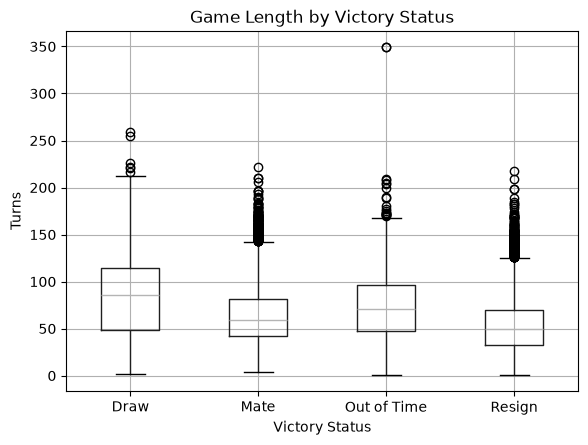

In [32]:
df = pd.read_csv("../data/raw/chess_games.csv")

os.makedirs("../output/plots", exist_ok=True)

plt.figure(figsize=(8,5))

df.boxplot(
    column='turns',
    by='victory_status'
)

plt.title("Game Length by Victory Status")
plt.suptitle("")
plt.xlabel("Victory Status")
plt.ylabel("Turns")

plt.savefig("../output/plots/box_turns_by_victory_status.png", bbox_inches='tight')
plt.show()